# Regresion Basica: Predecir eficiencia de gasolina

Este libro usa el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) y construye un modelo para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Este ejemplo usa el API `tf.keras` , revise [Esta Guia](https://www.tensorflow.org/guide/keras) para obtener mas detalles.

## El set de Datos de MPG

El set de datos esta disponible de el siguiente repositorio [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/).

### Obtenga los datos
Primero descargue el set de datos.
keras.utils.get_file("auto-mpg.data", "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

In [79]:
column_names = ["MPG", "Cylinders", "Displacement", "Horsepower", "Weight", "Acceleration", "Model Year", "Origin", "Car name"]

In [80]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

Importelo usando pandas.

In [81]:
import pandas as pd
df = pd.read_csv(url,sep=r'\s+', names=column_names,na_values="?"
)

### Limpia los datos

Trata los missings y variables categóricas

In [82]:
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,Car name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
 8   Car name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [84]:
df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())

In [85]:
df['Origin'] = df['Origin'].map({1: 'usa', 2: 'europe', 3: 'japan'})

# Aplicamos One-Hot Encoding (esto crea columnas individuales para cada origen)
df = pd.get_dummies(df, columns=['Origin'], prefix='', prefix_sep='')


In [86]:
df.drop("Car name", axis=1, inplace=True)

### Divide los datos en train y test

Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo.

NOTA: El resultado tienen que ser dos datasets

In [87]:
from sklearn.model_selection import train_test_split
X = df.drop('MPG', axis=1)
y = df['MPG']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Inspecciona los datos

Revise rapidamente la distribucion conjunta del dataset de entrenamiento mediante un grid de gráficos

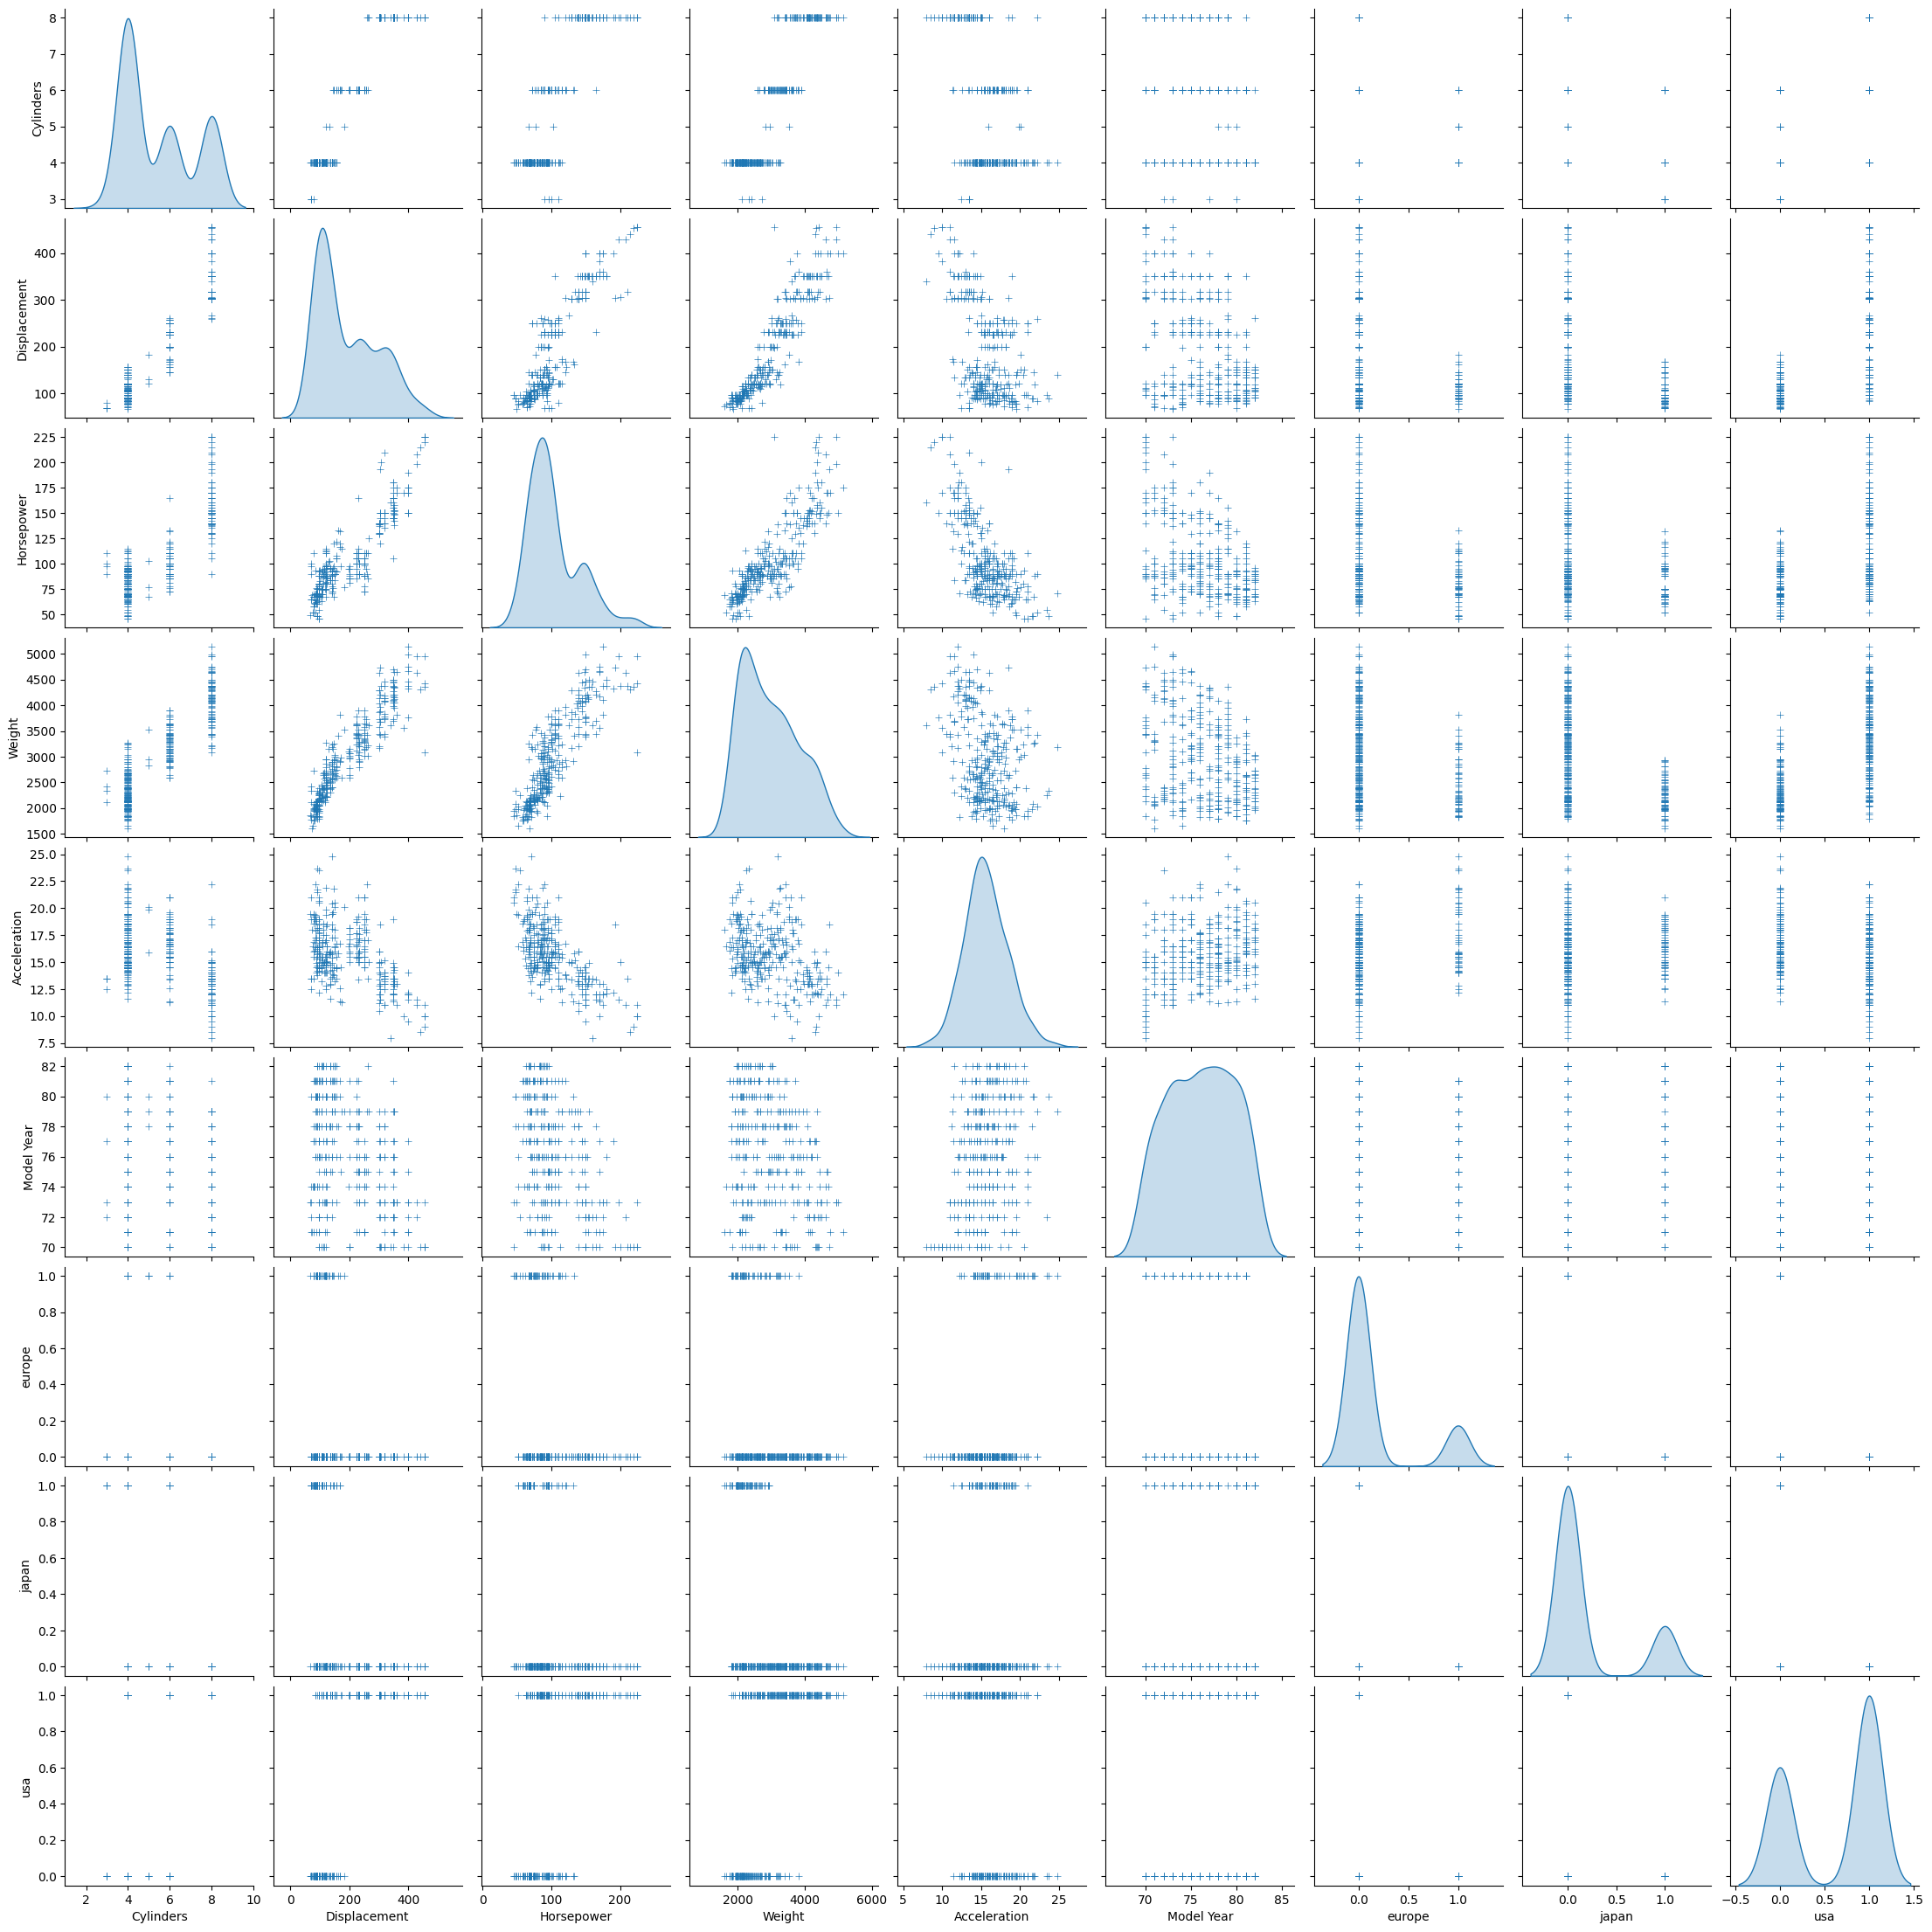

In [88]:
import seaborn as sns

sns.pairplot(X_train, 
             diag_kind="kde", 
             markers="+")

Tambien revise las estadisticas generales:

### Separa las features del target

Separe el target de las features.

In [89]:
X = df.drop('MPG', axis=1)
y = df['MPG']

### Estandariza los datos

Es una buena práctica estandarizar funciones que utilizan diferentes escalas y rangos. Aunque el modelo podría converger sin estandarizar, dificulta el entrenamiento y hace que el modelo resultante dependa de la elección de las unidades utilizadas en la entrada.

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Estos datos estandarizados es lo que usaremos para entrenar el modelo.

## El modelo

### Construye el modelo

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo.

Por tanto, tendrá tres capas. Una de entrada con activación relu. Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres para las dos primeras capas.

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

In [91]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model.compile(
    loss='mse',  # Mean Squared Error para regresión
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    metrics=['mae', 'mse']  # Mean Absolute Error y Mean Squared Error
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Inspeccione el modelo

Use el método `.summary` para imprimir una descripción simple del modelo

In [92]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753 (10.75 KB)

 Trainable params: 2,753 (10.75 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenar el modelo

Entrene el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

NOTA: recuerda usar los datos normalizados.

In [93]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=1000,
    batch_size=32,
    verbose=1,
)

Epoch 1/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 16354.4053 - mae: 80.1988 - mse: 16354.4053 - val_loss: 142.0076 - val_mae: 10.0146 - val_mse: 142.0076
Epoch 2/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 149.4590 - mae: 10.3636 - mse: 149.4590 - val_loss: 134.8054 - val_mae: 9.7881 - val_mse: 134.8054
Epoch 3/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 143.0145 - mae: 10.0537 - mse: 143.0145 - val_loss: 135.5496 - val_mae: 9.6988 - val_mse: 135.5496
Epoch 4/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 145.9549 - mae: 10.0739 - mse: 145.9549 - val_loss: 171.8263 - val_mae: 10.6908 - val_mse: 171.8263
Epoch 5/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 440.0269 - mae: 16.1648 - mse: 440.0269 - val_loss: 2152.9521 - val_mae: 46.1736 - val_mse: 2152.9521
Epoch 6/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 806.6768 - mae: 24.0969 - mse: 806.6768 - val_loss: 448.3037 - val_mae: 20.2768 - val_mse: 448.3037
Epoch 7/1000
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1

Visualice el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`.

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])
dict_values([[16354.4052734375, 149.458984375, 143.0144805908203, 145.95494079589844, 440.0268859863281, 806.6767578125, 751.97412109375, 772.2811889648438, 277.8210754394531, 1010.444580078125, 414.2295837402344, 891.95556640625, 450.40753173828125, 723.2816162109375, 711.664794921875, 694.6822509765625, 88.64564514160156, 1289.266357421875, 248.32858276367188, 816.0814208984375, 321.37017822265625, 847.38232421875, 338.0012512207031, 962.8809814453125, 155.22592163085938, 799.1443481445312, 567.4767456054688, 545.6914672851562, 486.2234802246094, 516.2562866210938, 930.7045288085938, 107.46874237060547, 867.2158813476562, 622.5863037109375, 306.94232177734375, 787.27001953125, 541.9715576171875, 504.1212463378906, 536.094482421875, 554.514892578125, 433.88165283203125, 723.9129638671875, 166.95306396484375, 807.6548461914062, 522.937255859375, 730.8851318359375, 254.83787536621094, 784.3848876953125, 190.948837280273

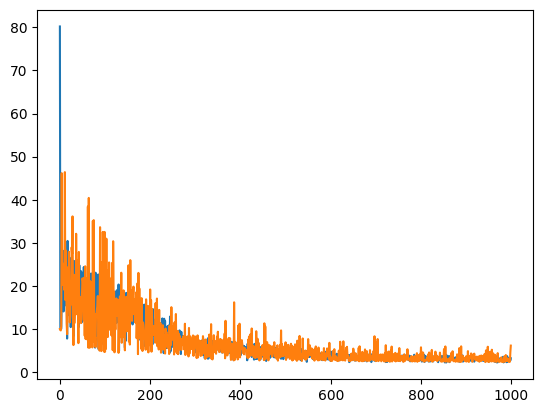

In [94]:
history_dict = history.history

print(history_dict.keys())
print(history_dict.values(
    
))

history_dict['loss']

mae = history_dict['mae']
val_mae = history_dict['val_mae']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mse = history_dict['mse']
val_mse = history_dict['val_mse']


plt.plot(mae, label='Training MAE')
plt.plot(val_mae, label='Validation MAE')

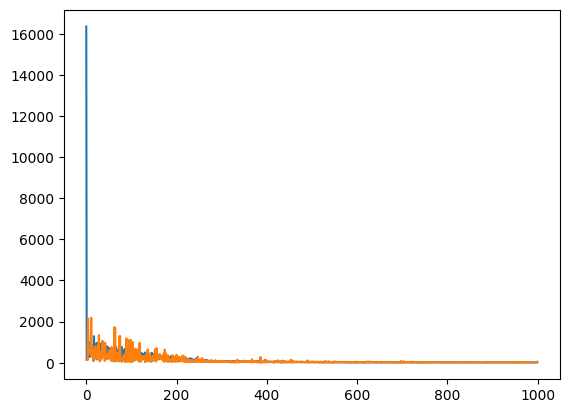

In [95]:
plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')

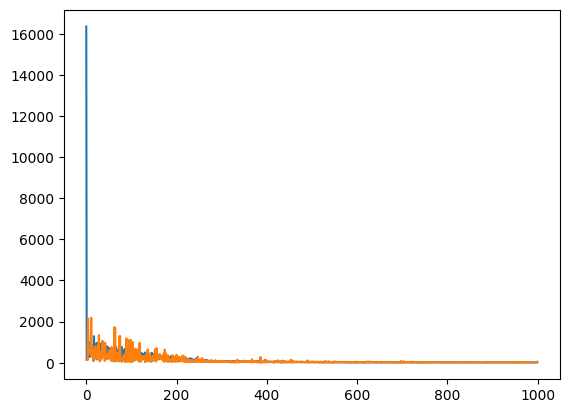

In [96]:
plt.plot(mse, label='Training mse')
plt.plot(val_mse, label='Validation mse')

¿Alguna conclusión respecto a este gráfico?

el modelo se estabiliza despues de la diferencia inciial. al 600 se estabiliza . Posiblmenetebajando el epochs mejorariamos porque es ucho aprendizaje para tan pocos datos.

Earlystopping me ha ayudado a detener el entrenamiento para no caer en overfitting, también para ahorrar recursos innecesarios.

Observamos que si le damos muchas epochs al entrenamiento tiende a un overfitting, siendo el error en validación cada vez más alto. Sería interesante utilizar un número aprox de 30 epochs

Añade un early stopping al modelo. Pon el argumento `callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)]` dentro del fit().

Visualiza el progreso de entrenamiento.

In [97]:
import keras
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)]
)

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 14.2434 - mae: 2.7819 - mse: 14.2434 - val_loss: 10.5667 - val_mae: 2.4016 - val_mse: 10.5667
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 15.8038 - mae: 3.1055 - mse: 15.8038 - val_loss: 13.8558 - val_mae: 3.1160 - val_mse: 13.8558
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.9771 - mae: 2.8840 - mse: 13.9771 - val_loss: 12.9435 - val_mae: 2.9769 - val_mse: 12.9435
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 13.0521 - mae: 2.7615 - mse: 13.0521 - val_loss: 34.9613 - val_mae: 5.2039 - val_mse: 34.9613
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16.6524 - mae: 3.0431 - mse: 16.6524 - val_loss: 13.0177 - val_mae: 2.9460 - val_mse: 13.0177
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 12.8679 - mae: 2.8209 - mse: 12.8679 - val_loss: 22.2294 - val_mae: 4.0730 - val_mse: 22.2294
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 18.8888 - mae: 3.5563 - mse: 18.8888 

Interpreta el gráfico

dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])
dict_values([[14.243362426757812, 15.803803443908691, 13.977108001708984, 13.052124977111816, 16.65241050720215, 12.867852210998535, 18.88878059387207, 11.685399055480957, 20.200075149536133, 15.908541679382324, 12.334246635437012, 12.739667892456055, 16.260940551757812, 15.427947998046875, 10.030354499816895, 16.217594146728516, 14.11943244934082, 12.18456745147705, 17.521081924438477, 18.886066436767578, 11.006364822387695, 16.12334632873535, 14.164098739624023, 15.466137886047363, 13.86678409576416, 18.611143112182617, 12.110946655273438], [2.781851053237915, 3.1054508686065674, 2.8839566707611084, 2.7614657878875732, 3.0431034564971924, 2.820862293243408, 3.5562803745269775, 2.5492606163024902, 3.6401727199554443, 3.071317195892334, 2.6219077110290527, 2.672809600830078, 2.980642318725586, 3.144521474838257, 2.2586891651153564, 3.1884591579437256, 2.9546732902526855, 2.6235196590423584, 3.221902847290039, 3.5892035

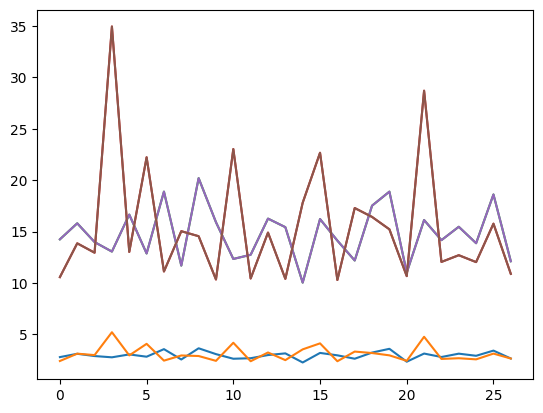

In [98]:
history_dict = history.history

print(history_dict.keys())
print(history_dict.values())

history_dict['loss']

mae = history_dict['mae']
val_mae = history_dict['val_mae']
loss = history_dict['loss']
val_loss = history_dict['val_loss']
mse = history_dict['mse']
val_mse = history_dict['val_mse']


plt.plot(mae, label='Training MAE')
plt.plot(val_mae, label='Validation MAE')
plt.plot(loss, label='Training loss')
plt.plot(val_loss, label='Validation loss')
plt.plot(mse, label='Training mse')
plt.plot(val_mse, label='Validation mse')

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [99]:
test_loss, test_mae, test_mse = model.evaluate(X_test_scaled, y_test, verbose=1)

print("\n=== EVALUACIÓN DEL MODELO CON DATOS DE PRUEBA ===")
print(f"Pérdida (MSE) en prueba: {test_loss:.4f}")
print(f"Error Absoluto Medio (MAE) en prueba: {test_mae:.4f} MPG")
print(f"Error Cuadrático Medio (MSE) en prueba: {test_mse:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 525.0349 - mae: 21.9669 - mse: 525.0349 

=== EVALUACIÓN DEL MODELO CON DATOS DE PRUEBA ===
Pérdida (MSE) en prueba: 525.0349
Error Absoluto Medio (MAE) en prueba: 21.9669 MPG
Error Cuadrático Medio (MSE) en prueba: 525.0349


Ahora prueba el modelo. Coge 10 ejemplos de test y llama a` model.predict`.

In [100]:
import numpy as np
y_pred = model.predict(X_test)

resultados = pd.DataFrame({
    'Valor Real': y_test.values.flatten(),
    'Valor Predicho': y_pred.flatten(),
    'Error Absoluto': np.abs(y_test.values.flatten() - y_pred.flatten()),
    'Error Porcentual': np.abs((y_test.values.flatten() - y_pred.flatten()) / y_test.values.flatten()) * 100
})

print(resultados.head(10))
print(f"Error Absoluto Medio (MAE): {resultados['Error Absoluto'].mean():.4f} MPG")
print(f"Error Absoluto Máximo: {resultados['Error Absoluto'].max():.4f} MPG")
print(f"Error Absoluto Mínimo: {resultados['Error Absoluto'].min():.4f} MPG")
print(f"Desviación Estándar del Error: {resultados['Error Absoluto'].std():.4f}")
print(f"Error Porcentual Medio: {resultados['Error Porcentual'].mean():.2f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
   Valor Real  Valor Predicho  Error Absoluto  Error Porcentual
0        33.0       35.665340        2.665340          8.076789
1        28.0       29.656845        1.656845          5.917304
2        19.0       21.209000        2.209000         11.626314
3        13.0       16.989485        3.989485         30.688345
4        14.0       15.204022        1.204022          8.600160
5        27.0       28.471270        1.471270          5.449147
6        24.0       26.874458        2.874458         11.976910
7        13.0       14.213924        1.213924          9.337880
8        17.0       17.697535        0.697535          4.103144
9        21.0       21.485891        0.485891          2.313768
Error Absoluto Medio (MAE): 1.9908 MPG
Error Absoluto Máximo: 9.2332 MPG
Error Absoluto Mínimo: 0.0852 MPG
Desviación Estándar del Error: 1.5839
Error Porcentual Medio: 9.40%


### Haz Predicciones

Dibuja en un scatter plot las predicciones de test vs sus true labels.

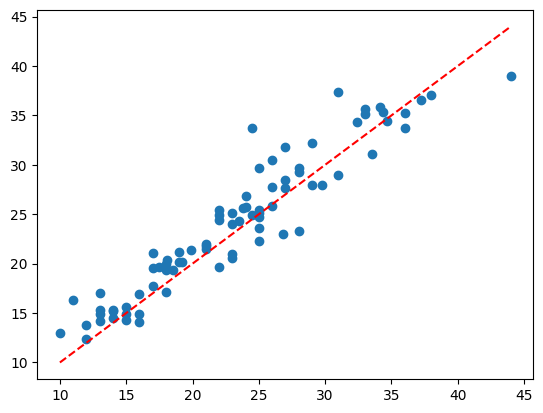

In [101]:

plt.scatter(resultados['Valor Real'], resultados['Valor Predicho'])

max_val = resultados['Valor Real'].max()
min_val = resultados['Valor Real'].min()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal')


Parece que nuestro modelo predice razonablemente bien. Echemos un vistazo a la distribución de errores.

Representa los residuos en un histograma

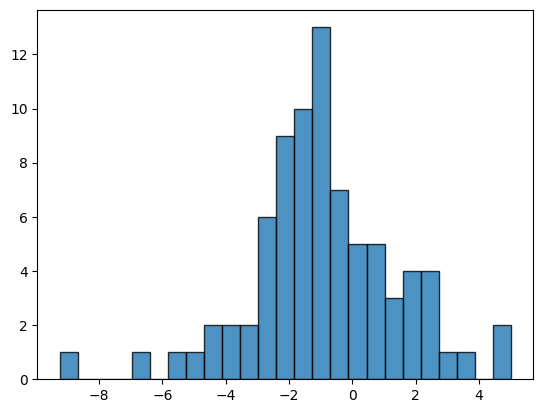

In [102]:
residuos = resultados['Valor Real'] - resultados['Valor Predicho']

plt.hist(residuos, bins=25, edgecolor='black', alpha=0.8)
plt.show()

No es del todo gaussiano, pero podríamos esperar eso porque el número de muestras es muy pequeño.

Guarda tu modelo en un archivo.

In [103]:
model.save('mi_modelo_mpg.keras')

## Conclusion

En la grafica scatterplot vemos que sigue una tendencia de 45% por lo tanto podríamos decir que las predicciones son bastante acertadas.

Importante no pasarnos de epochs con los primeros 1000 nos habiamos pasad ya que tenemos pocos datos .